 Sign Language MNIST

### Machine Learning Techniques:
- PCA
- KNN
- Decision Tree
- Random Forest
- K-Means Clustering

In [ ]:
print("hi")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    adjusted_rand_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
import pandas as pd

train_df = pd.read_csv(r"C:\Users\Admin\mnisttt\sign_mnist_train.csv")
test_df = pd.read_csv(r"C:\Users\Admin\mnisttt\sign_mnist_test.csv")

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)
train_df.head()

Training data: (27455, 785)
Testing data : (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [6]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None


In [7]:
print("Number of classes:", train_df["label"].nunique())
print("Labels:", sorted(train_df["label"].unique()))

Number of classes: 24
Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [8]:
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (27455, 784)
y_train: (27455,)
X_test : (7172, 784)
y_test : (7172,)


In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel values:", X_train.min().min(), "to", X_train.max().max())

Pixel values: 0.0 to 1.0


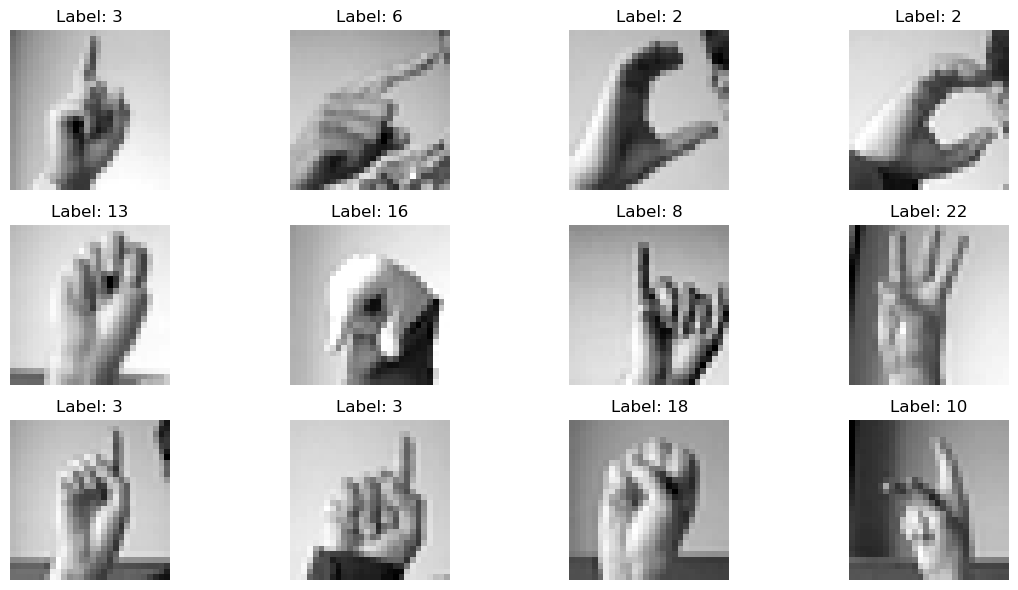

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    
    image = X_train.iloc[i].values.reshape(28, 28)
    
    plt.imshow(image, cmap="gray")
    plt.title("Label: " + str(y_train.iloc[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

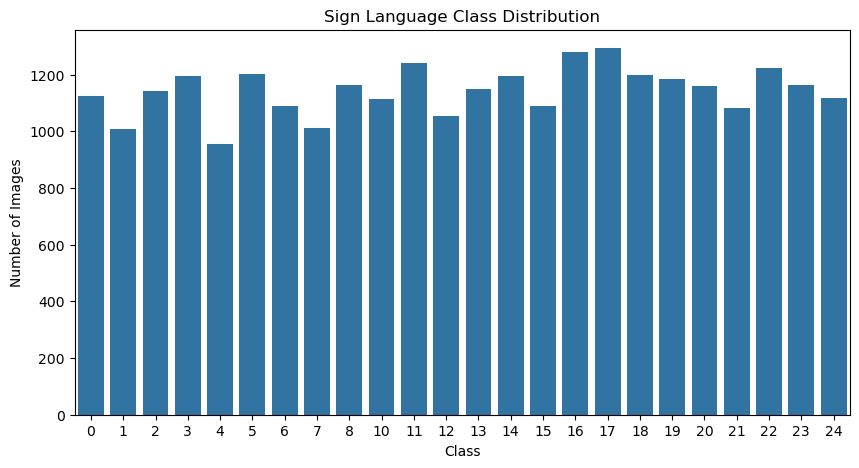

In [11]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(x=y_train)

plt.title("Sign Language Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original features:", X_train.shape[1])
print("Features after PCA:", X_train_pca.shape[1])
print("Training shape:", X_train_pca.shape)
print("Testing shape:", X_test_pca.shape)

Original features: 784
Features after PCA: 100
Training shape: (27455, 100)
Testing shape: (7172, 100)


In [13]:
print("Explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: 0.9423434638180139


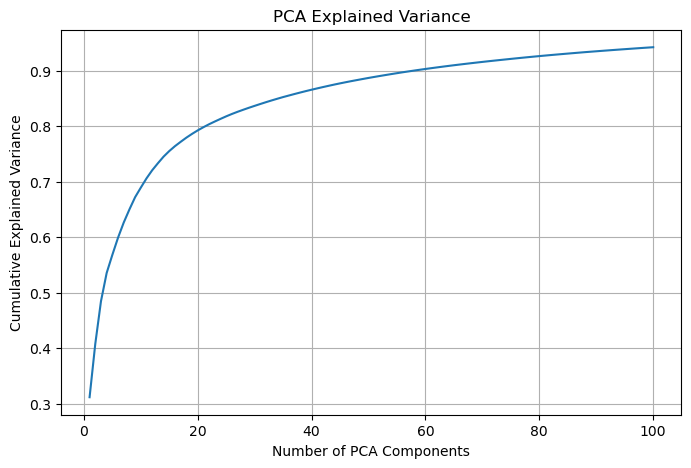

In [14]:
import numpy as np
import matplotlib.pyplot as plt

variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), variance)

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)

print("KNN prediction completed!")

KNN prediction completed!


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average="weighted")
knn_recall = recall_score(y_test, y_pred_knn, average="weighted")
knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

print("KNN Results")
print("----------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Results
----------------
Accuracy : 0.8156720580033463
Precision: 0.8338241102998792
Recall   : 0.8156720580033463
F1 Score : 0.8163715714085146


In [17]:
k_values = [3, 5, 7, 9]

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_pca, y_train)
    
    pred = knn_temp.predict(X_test_pca)
    acc = accuracy_score(y_test, pred)
    
    print("K =", k, "Accuracy =", acc)

K = 3 Accuracy = 0.8165086447295036
K = 5 Accuracy = 0.8156720580033463
K = 7 Accuracy = 0.8089793641940881
K = 9 Accuracy = 0.8060513106525377


In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt.fit(X_train_pca, y_train)

y_pred_dt = dt.predict(X_test_pca)

print("Decision Tree prediction completed!")

Decision Tree prediction completed!


In [19]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(
    y_test, y_pred_dt, average="weighted"
)
dt_recall = recall_score(
    y_test, y_pred_dt, average="weighted"
)
dt_f1 = f1_score(
    y_test, y_pred_dt, average="weighted"
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.39375348577802566
Precision: 0.4226395058259522
Recall   : 0.39375348577802566
F1 Score : 0.39965404210532973


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

y_pred_rf = rf.predict(X_test_pca)

print("Random Forest prediction completed!")

Random Forest prediction completed!


In [21]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test, y_pred_rf, average="weighted"
)

rf_recall = recall_score(
    y_test, y_pred_rf, average="weighted"
)

rf_f1 = f1_score(
    y_test, y_pred_rf, average="weighted"
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.7703569436698271
Precision: 0.7918401032627783
Recall   : 0.7703569436698271
F1 Score : 0.7718434283724908


In [24]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        knn_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        knn_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        knn_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        knn_f1,
        dt_f1,
        rf_f1
    ]
})

results





,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.815672,0.833824,0.815672,0.816372
1,Decision Tree,0.393753,0.422640,0.393753,0.399654
2,Random Forest,0.770357,0.791840,0.770357,0.771843


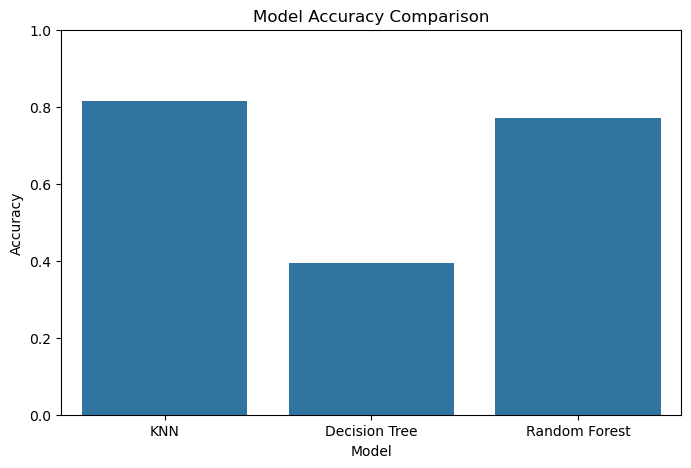

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()